# Coin-selection project
### Python

## Load libraries and simulation results

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

from pprint import pp
from src import util

In [8]:
# Assuming files are stored in "saved-fees-updated" directory
data_dir = '../coin-selection-c-master/simulation/results'
files = os.listdir(data_dir)
csv_files = (f for f in files if f.endswith(".csv"))
json_files = (f for f in files if f.endswith(".json"))
stat_files = (f for f in files if f.endswith(".ccsv"))

# Predefined colors for each strategy
strategy_colors = {
#    'MAX_BILLS': 'blue',
#    'CLOSEST_TO_EXPIRE_MIN_BILLS': 'orange',
#    'CLOSEST_TO_EXPIRE_MAX_BILLS': 'red',
#    'MAX_BILLS_TIME_TO_EXPIRE_WEIGHTED': 'yellow',
    'RANDOM': 'magenta',
    'MIN_BILLS': 'cyan',
    'EVEN_FROM_MIN_TO_MAX': 'red',
    'EVEN_FROM_MAX_TO_MIN': 'pink',
    'GREEDY_MIN_TO_MAX': 'purple',
    'GREEDY_MIN_TO_MAX_FIX': 'red',
#    'CALL_EXTERNAL': 'yellow',
 #   'CALL_EXTERNAL_0': 'black',
    'WALLET_CORE': 'green'
}


stats = []

for file_name in stat_files:
    print(file_name)
    file_path = os.path.join(data_dir, file_name)
    with open(file_path, 'r') as file:
        user_type, strategy, cpu_time = file.readline().strip().split(',')
        stats.append({
            "UserType": user_type,
            "Strategy": strategy,
            "CPUTime": float(cpu_time)
        })    
            
# Initialize an empty list to hold all data
all_data = []
            
# Process each file
for file_name in csv_files:
    file_path = os.path.join(data_dir, file_name)
    with open(file_path, 'r') as file:
        # Read user type and strategy from the first line
        try:
            user_type, strategy = file.readline().strip().split(', ')
        except:
            continue
        # Parse the rest of the data
        for line in file:
            try:
                id, time, amount, operation, fee, coin_count = line.strip().split(', ')  # Updated here to include 'amount'
            except:
                continue
            all_data.append({
                "UserType": user_type,
                "Strategy": strategy,
                "Id": id,
                "Time": int(time),
                "Amount": int(amount),  
                "Operation": operation,  
                "Fee": int(fee),
                "FileName": file_name,
                "CoinCount": int(coin_count)
            })


# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(all_data)

df.describe()



stats_user_0_strategy_CLOSEST_TO_EXPIRE_MAX_BILLS.ccsv
stats_user_0_strategy_GREEDY_MIN_TO_MAX_FIX.ccsv
stats_user_0_strategy_WALLET_CORE.ccsv
stats_user_0_strategy_EVEN_FROM_MIN_TO_MAX.ccsv
stats_user_0_strategy_MIN_BILLS.ccsv
stats_user_0_strategy_GREEDY_MIN_TO_MAX.ccsv
stats_user_0_strategy_MAX_BILLS_TIME_TO_EXPIRE_WEIGHTED.ccsv
stats_user_0_strategy_EVEN_FROM_MAX_TO_MIN.ccsv
stats_user_0_strategy_MAX_BILLS.ccsv
stats_user_0_strategy_CLOSEST_TO_EXPIRE_MIN_BILLS.ccsv
stats_user_0_strategy_RANDOM.ccsv


,Time,Amount,Fee,CoinCount
count,1.807400e+04,1.807400e+04,18074.000000,18074.000000
mean,4.764586e+07,3.273123e+05,5.627199,5152.321954
std,2.740515e+07,5.686716e+05,5.422176,4436.358242
min,2.592000e+05,0.000000e+00,1.000000,0.000000
25%,2.384640e+07,1.772800e+04,1.000000,1179.250000
50%,4.743360e+07,2.219000e+04,2.000000,4060.000000
75%,7.179840e+07,5.176260e+05,10.000000,8131.750000
max,9.322560e+07,1.999937e+06,58.000000,15045.000000


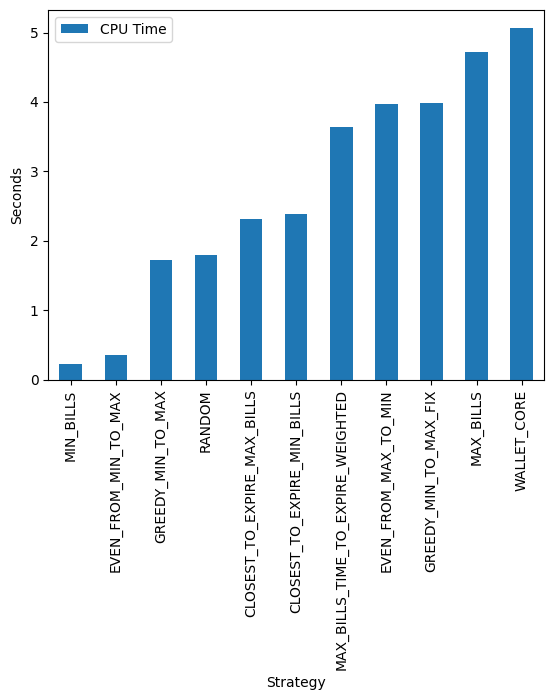

In [9]:
data_dir = '../coin-selection-c-master/simulation/results'
files = os.listdir(data_dir)
stat_files = (f for f in files if f.endswith(".ccsv"))

stats = []

for file_name in stat_files:
    file_path = os.path.join(data_dir, file_name)
    with open(file_path, 'r') as file:
        user_type, strategy, cpu_time = file.readline().strip().split(',')
        stats.append({
            "UserType": user_type,
            "Strategy": strategy,
            "CPU Time": float(cpu_time)
        })    

stat_df = pd.DataFrame(stats)
stat_df = stat_df.sort_values(by=["CPU Time"])

ax = stat_df.plot.bar(x="Strategy", ylabel="Seconds")
fig = ax.get_figure()
fig.savefig(f"pictures/CPUtime.png", bbox_inches='tight')

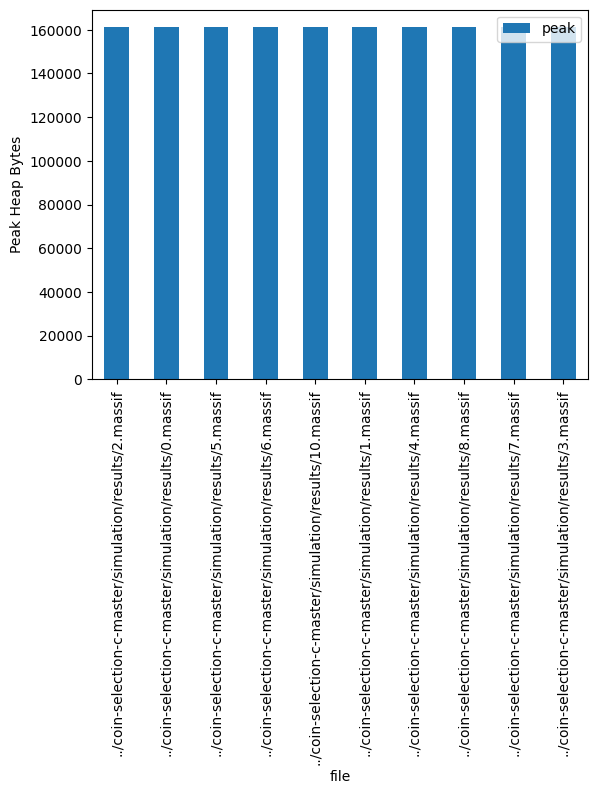

In [22]:
from src.util import load_massif

mem_data = load_massif()
mem_peak = [{"file": f, "peak": int(max(v)) }for f, v in mem_data.items()]

stat_df = pd.DataFrame(mem_peak)
stat_df = stat_df.sort_values(by=["peak"])

ax = stat_df.plot.bar(x="file", ylabel="Peak Heap Bytes")
fig = ax.get_figure()
fig.savefig(f"pictures/memory.png", bbox_inches='tight')

In [11]:
"""
json_data = util.load_all_files()
def len_true_len(items, key):
    return sum(1 for item in items if hasattr(item, key)), len(set(getattr(item, key) for item in items if hasattr(item, key)))

keys = sorted(json_data.keys())
pp(keys)
key, value = keys[0], json_data[keys[0]]
print(type(value), len(value))
print(type(value[0]), len(value[0]))
print(type(value[0][0]))
print(set(type(t) for t in value[0]))
print(len_true_len(value[0], "time"))
print(len(all_data), df.Time.unique().shape)
print(len_true_len(all_data, "Time"))
"""

'\njson_data = util.load_all_files()\ndef len_true_len(items, key):\n    return sum(1 for item in items if hasattr(item, key)), len(set(getattr(item, key) for item in items if hasattr(item, key)))\n\nkeys = sorted(json_data.keys())\npp(keys)\nkey, value = keys[0], json_data[keys[0]]\nprint(type(value), len(value))\nprint(type(value[0]), len(value[0]))\nprint(type(value[0][0]))\nprint(set(type(t) for t in value[0]))\nprint(len_true_len(value[0], "time"))\nprint(len(all_data), df.Time.unique().shape)\nprint(len_true_len(all_data, "Time"))\n'

## Generate cumulative fee for each user over time

missing CALL_EXTERNAL
missing CLOSEST_TO_EXPIRE_MAX_BILLS
missing CLOSEST_TO_EXPIRE_MIN_BILLS


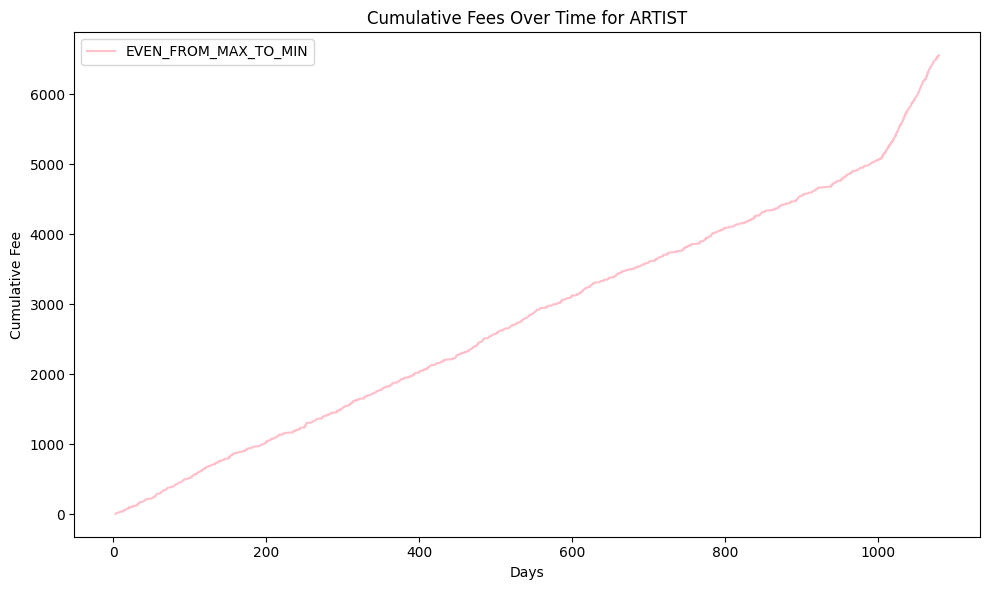

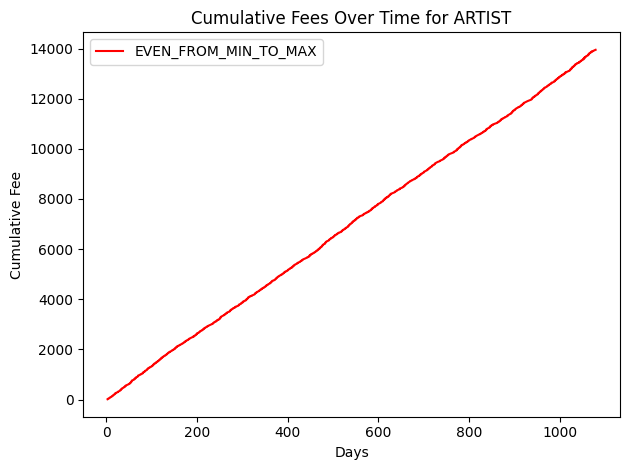

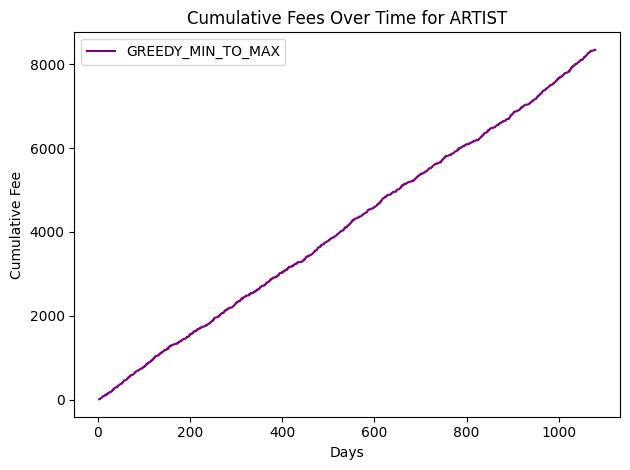

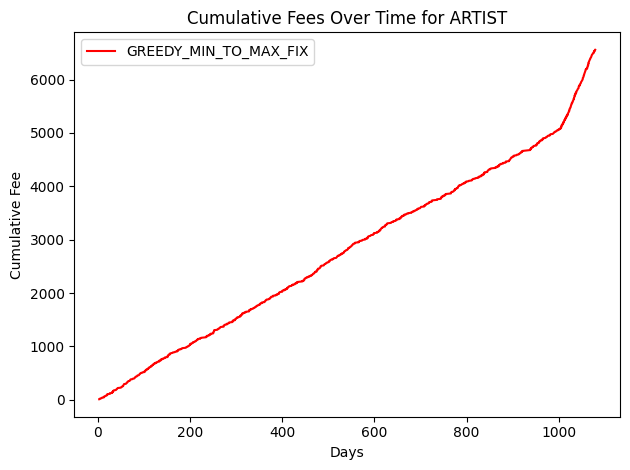

missing MAX_BILLS
missing MAX_BILLS_TIME_TO_EXPIRE_WEIGHTED


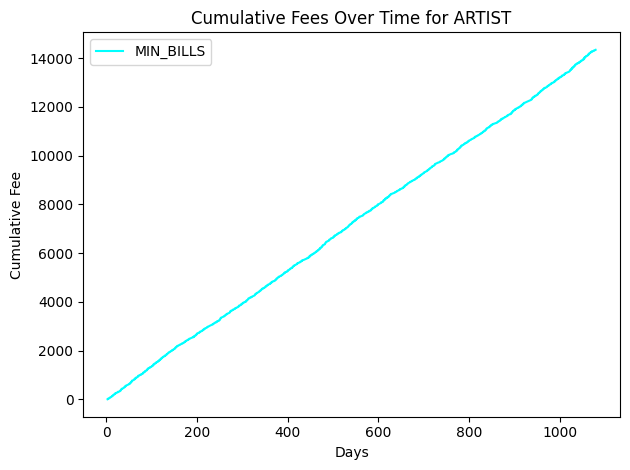

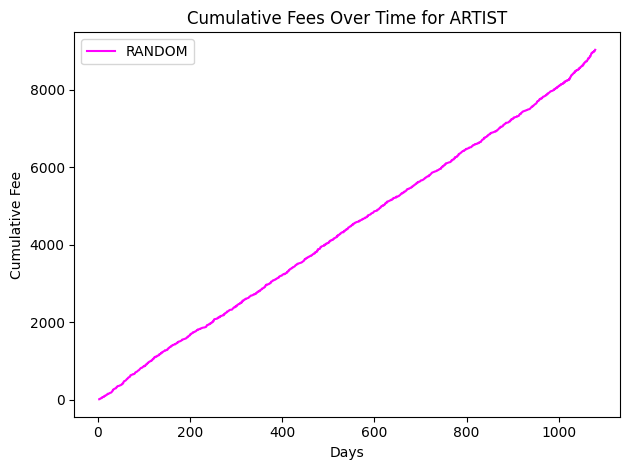

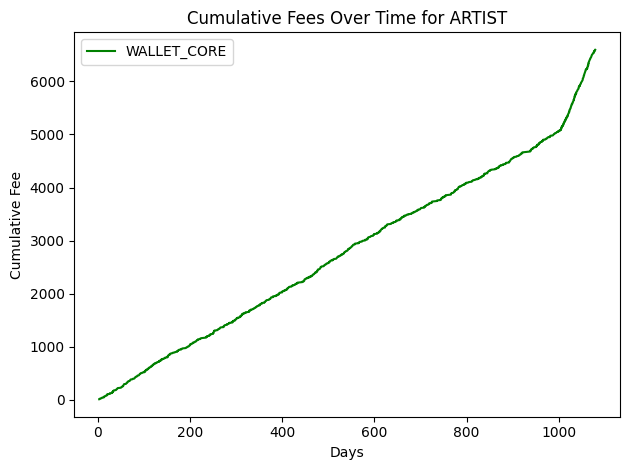

In [30]:

# Create a plot for each user type
for user_type in df['UserType'].unique():
    plt.figure(figsize=(10, 6))
    user_type_df = df.loc[(df['UserType'] == user_type)]

    # Plot cumulative fee for each user's data
    for file_name, user_df in user_type_df.groupby('FileName'):
        strategy = user_df['Strategy'].iloc[0]  # Strategy is the same for all rows of this user
        if strategy not in strategy_colors:
            print("missing", strategy)
            continue
        user_df = user_df.sort_values('Time').reset_index()
        user_df['CumulativeFee'] = user_df['Fee'].cumsum()
        user_df['Days'] = user_df['Time']/3600/24
        plt.plot(user_df['Days'], user_df['CumulativeFee'], label=strategy, color=strategy_colors[strategy])

                # Enhancing the plot
        plt.title(f"Cumulative Fees Over Time for {user_type}")
        plt.xlabel("Days")
        plt.ylabel("Cumulative Fee")
        plt.tight_layout()
    
        # Adding legend with color description
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())
    
        # Save the plot
        plt.savefig(f"pictures/{user_type}_{strategy}_cumulative_fees.png", bbox_inches='tight')
        plt.show()


## Plot histograms of fee values/amount of the transaction with this amount

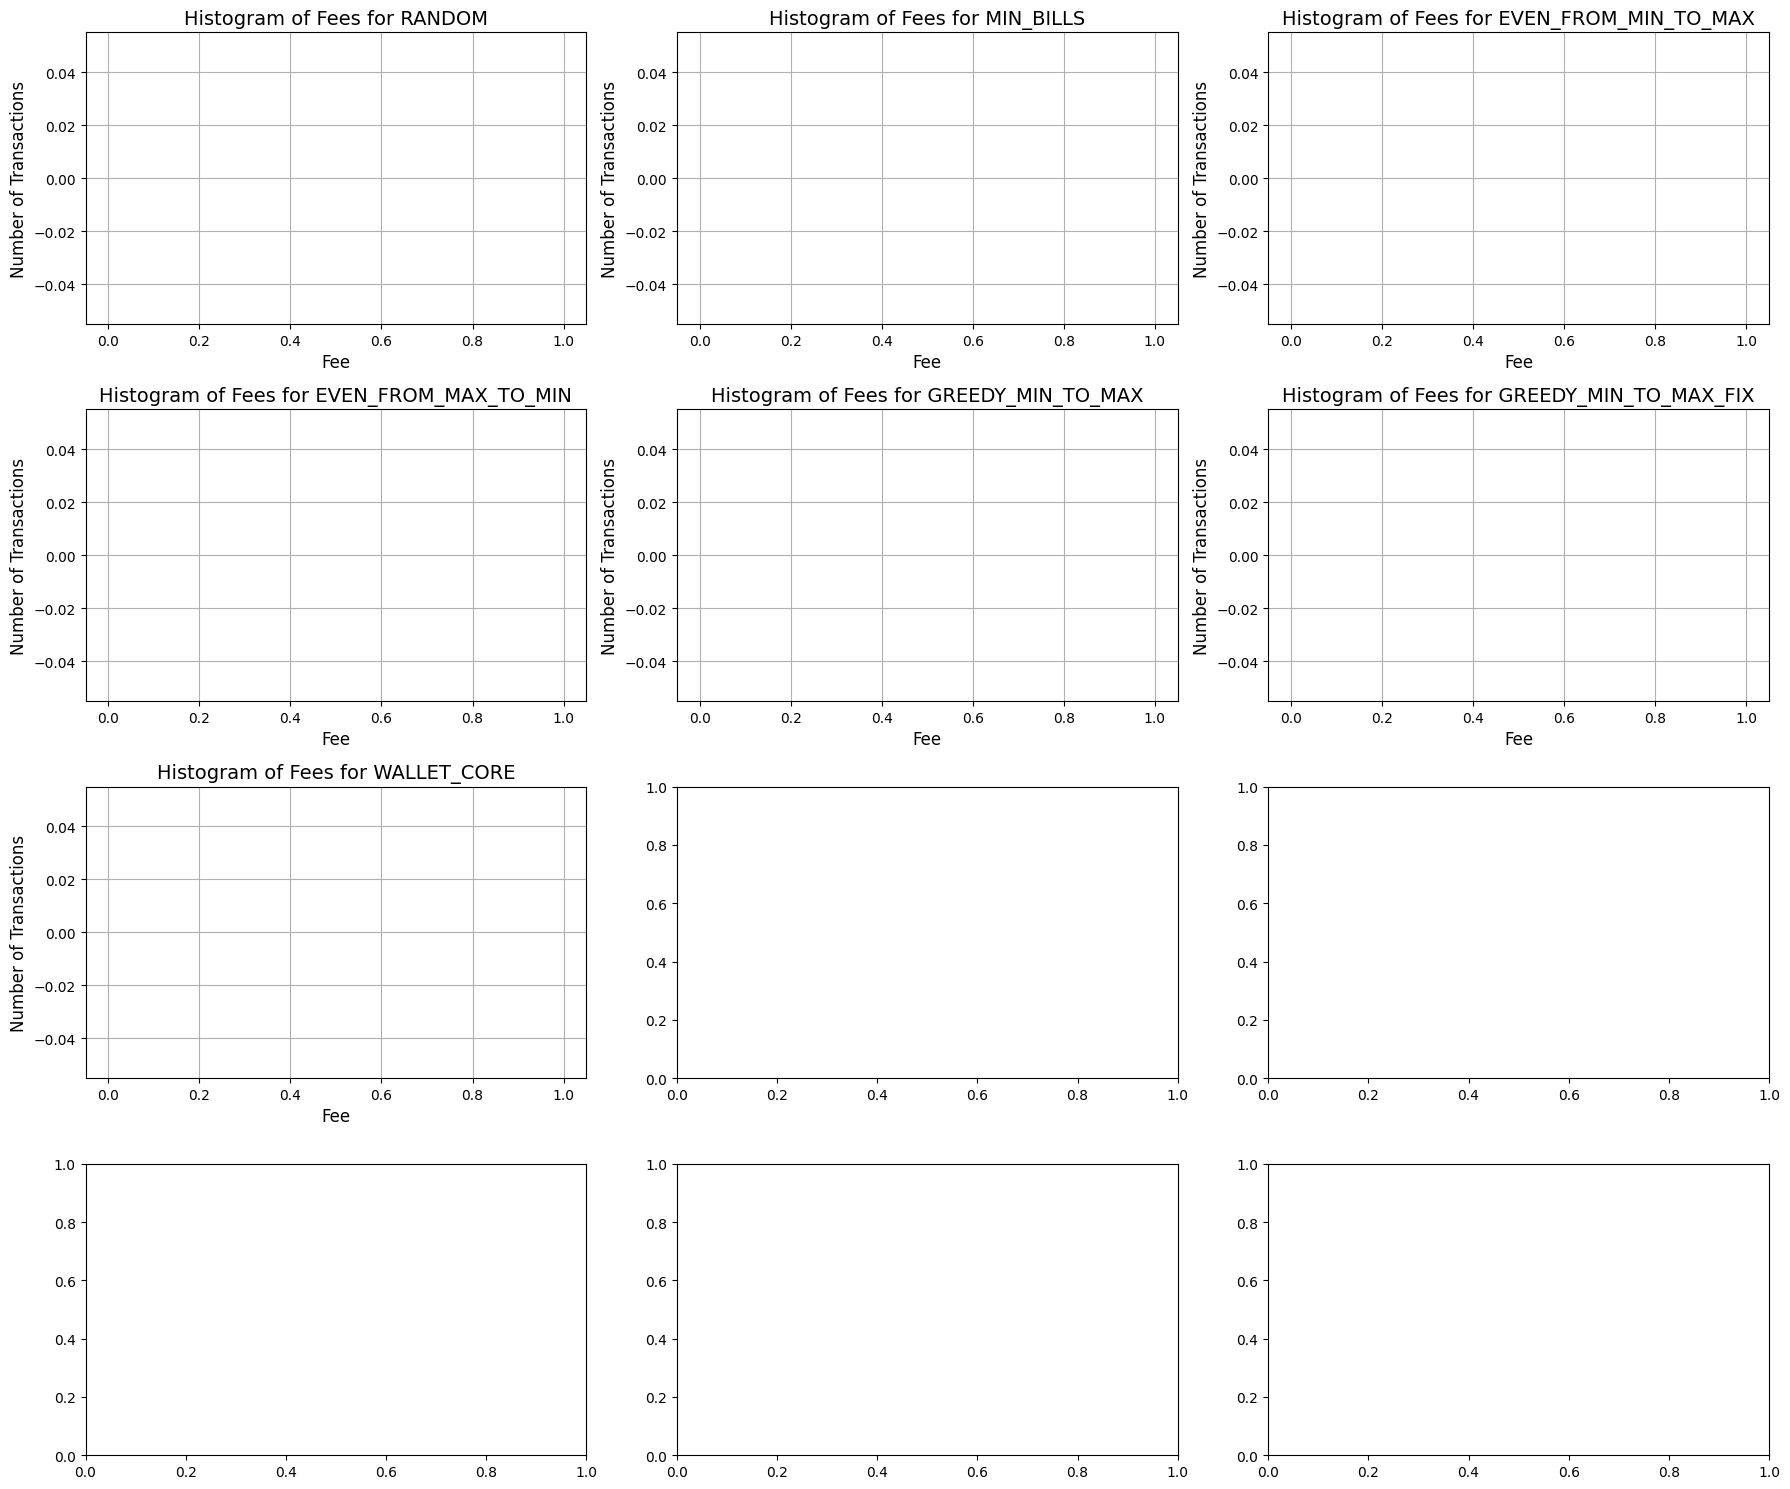

In [13]:
# Filter the DataFrame for WITHDRAW_OP operations and Amount > 0
df_filtered = df[(df['Operation'] == 'DEPOSIT_REFRESH_OP') & (df['Amount'] > 0) & (df['Amount'] < 500000)]

# Set up the figure for subplots
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 15))
axes = axes.ravel()  # Flatten the array of axes

# Iterate through each strategy and create a histogram in a separate subplot
for idx, (strategy, color) in enumerate(strategy_colors.items()):
    # Filter the DataFrame for the current strategy
    df_filtered_strategy = df_filtered[df_filtered['Strategy'] == strategy]

    # Plot the histogram for the current strategy
    axes[idx].hist(df_filtered_strategy['Fee'], bins=100, color=color, alpha=0.7)

    # Set labels and title for the subplot
    axes[idx].set_xlabel('Fee', fontsize=12)
    axes[idx].set_ylabel('Number of Transactions', fontsize=12)
    axes[idx].set_title(f'Histogram of Fees for {strategy}', fontsize=14)
    axes[idx].grid(True)

# Adjust the layout to prevent overlap
plt.tight_layout()
plt.savefig("results/histograms", bbox_inches='tight')
plt.show()

## Fit curves and display them on the plot of fee/transaction_amount

In [14]:
# Function to fit
def fit_function(amount, a, b, c):
    return a + b * amount + c * np.log(amount)

# Initialize dictionary for storing parameters
fitted_params = {}

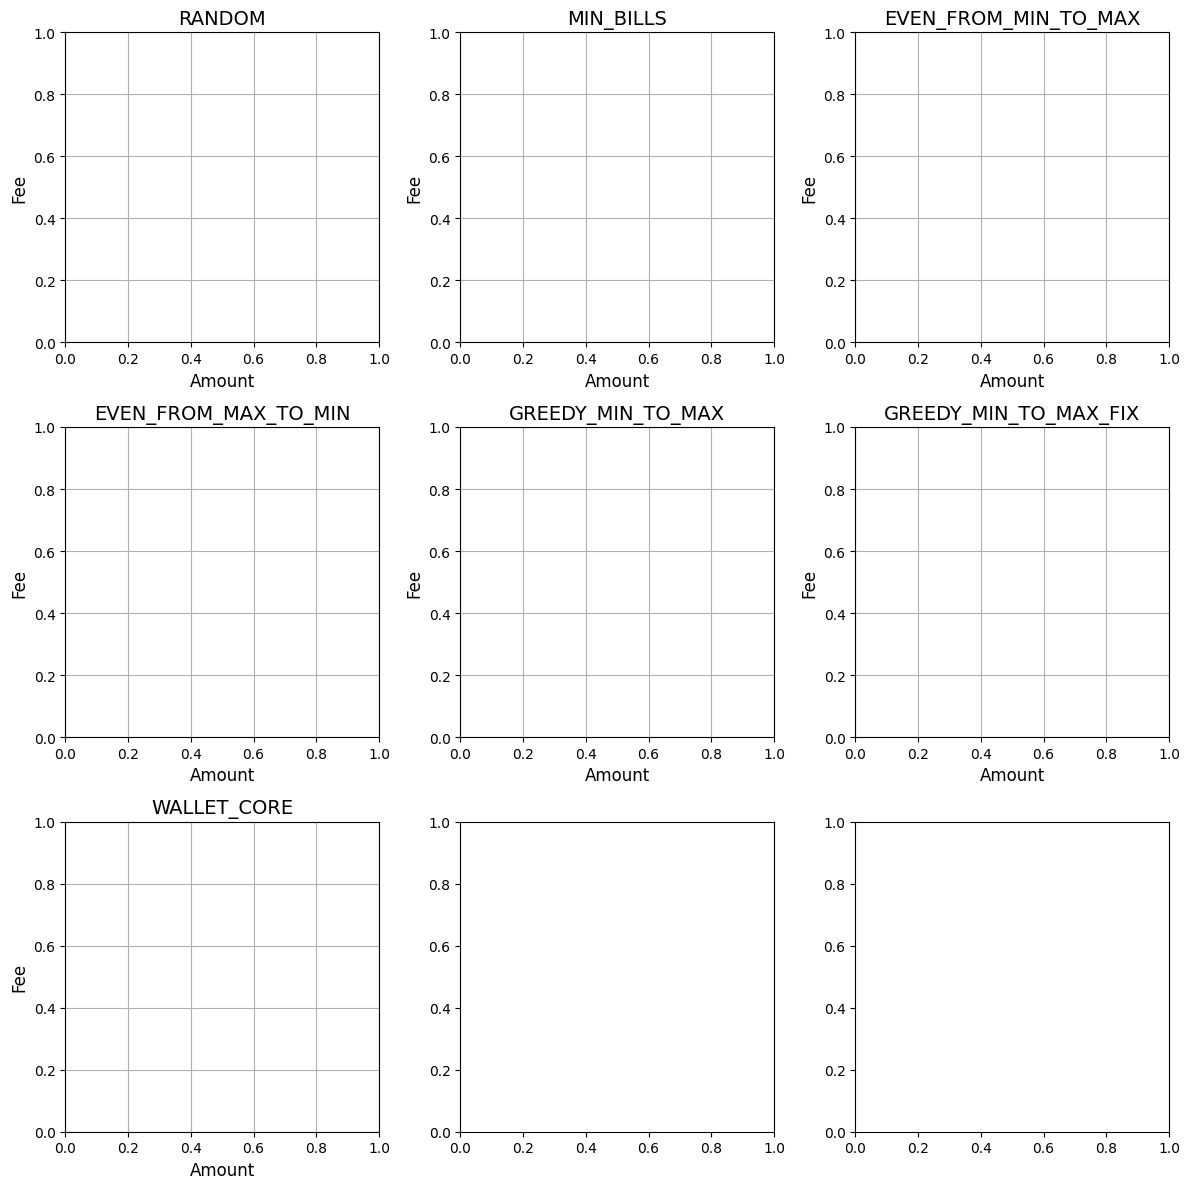

In [15]:
# Set up the figure for subplots with 2 rows and 3 columns
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
axes = axes.ravel()  # Flatten the array of axes

# Process each strategy
for i, (strategy, color) in enumerate(strategy_colors.items()):
    # Filter data for the current strategy
    strategy_data = df_filtered[df_filtered['Strategy'] == strategy]

    # Sort by 'Amount'
    strategy_sorted = strategy_data.sort_values(by='Amount')

    # Split into groups of 10,000 records each
    group_size = 10000
    list_of_groups = [strategy_sorted.iloc[j:j + group_size] for j in range(0, len(strategy_sorted), group_size)]

    # Collect data for fitting
    fit_amounts = np.array([])
    fit_fees = np.array([])

    # Plot each group and collect data points at or above the 99th percentile
    for group in list_of_groups:
        if not group.empty:
            axes[i].scatter(group['Amount'], group['Fee'], color='grey', alpha=0.05)  
            percentile_99 = np.percentile(group['Fee'], 99)
            selected_data = group[group['Fee'] >= percentile_99]
            axes[i].scatter(selected_data['Amount'], selected_data['Fee'], color='blue', alpha=0.05)
            fit_amounts = np.concatenate((fit_amounts, selected_data['Amount']))
            fit_fees = np.concatenate((fit_fees, selected_data['Fee']))

    if len(fit_amounts) > 0 and len(fit_fees) > 0:
        # Approach with limited parameter values
        # Define bounds: lower bounds as 0 and upper bounds as inf for all parameters
        lower_bounds = [0, 0, 0]
        upper_bounds = [np.inf, np.inf, np.inf]
        params, _ = curve_fit(fit_function, fit_amounts, fit_fees, bounds=(lower_bounds, upper_bounds))
        
        # Standard approach with no limits
        # params, _ = curve_fit(fit_function, fit_amounts, fit_fees)
        fitted_params[strategy] = params  
        fitted_amounts = np.linspace(min(fit_amounts), max(fit_amounts), 400)
        fitted_fees = fit_function(fitted_amounts, *params)
        axes[i].plot(fitted_amounts, fitted_fees, 'r-', label=f'Fit: a={params[0]:.2f}, b={params[1]:.2f}, c={params[2]:.2f}')
        axes[i].legend()

    # Set titles and labels
    axes[i].set_title(f"{strategy}", fontsize=14)
    axes[i].set_xlabel('Amount', fontsize=12)
    axes[i].set_ylabel('Fee', fontsize=12)
    axes[i].grid(True)

# Adjust the layout to prevent overlap
plt.tight_layout()
plt.savefig("results/fitted_params", bbox_inches='tight')
plt.show()

In [16]:
# Now you can use 'fitted_params' for further analysis or plots
print("Fitted parameters for each strategy:")
for strat, params in fitted_params.items():
    print(f"{strat}: a={params[0]:.2f}, b={params[1]:.2f}, c={params[2]:.2f}")

Fitted parameters for each strategy:


## Plot the fee/amount with te same fee scale for all subplots

ValueError: Axis limits cannot be NaN or Inf

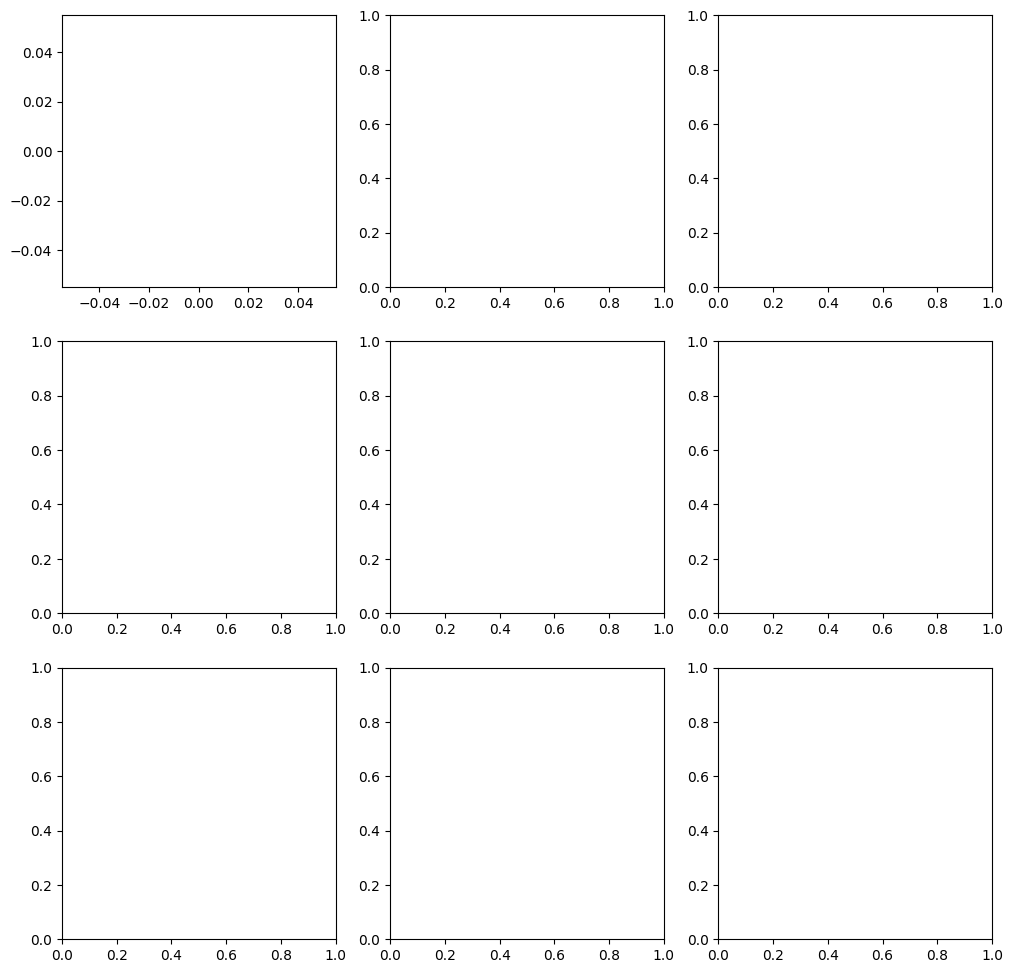

In [17]:
# Set up the figure for subplots with 2 rows and 3 columns
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
axes = axes.ravel() 

# Determine global min and max for Amount and Fee to ensure consistent scaling
global_min_amount = df_filtered['Amount'].min()
global_max_amount = df_filtered['Amount'].max()
global_min_fee = df_filtered['Fee'].min()
global_max_fee = df_filtered['Fee'].max()

# Process each strategy
for i, (strategy, color) in enumerate(strategy_colors.items()):
    # Filter data for the current strategy
    strategy_data = df_filtered[df_filtered['Strategy'] == strategy]

    # Sort by 'Amount'
    strategy_sorted = strategy_data.sort_values(by='Amount')

    # Plot data with global scaling
    axes[i].scatter(strategy_sorted['Amount'], strategy_sorted['Fee'], color='grey', alpha=0.05)  # Normal points in grey

    # Calculate and plot the 99th percentile for each group
    group_size = 10000
    for j in range(0, len(strategy_sorted), group_size):
        group = strategy_sorted.iloc[j:j+group_size]
        if not group.empty:
            percentile_99 = np.percentile(group['Fee'], 98)
            selected_data = group[group['Fee'] >= percentile_99]
            axes[i].scatter(selected_data['Amount'], selected_data['Fee'], color='blue', alpha=0.05)  # 99th percentile in blue

    # Use the fitted parameters to plot the curve if they exist
    if strategy in fitted_params:
        params = fitted_params[strategy]
        fitted_amounts = np.linspace(global_min_amount, global_max_amount, 400)
        fitted_fees = fit_function(fitted_amounts, *params)
        axes[i].plot(fitted_amounts, fitted_fees, 'r-', label=f'Fit: a={params[0]:.2f}, b={params[1]:.2f}, c={params[2]:.2f}')
        axes[i].legend()

    # Set axes limits and titles
    axes[i].set_xlim([global_min_amount, global_max_amount])
    axes[i].set_ylim([global_min_fee, global_max_fee])
    axes[i].set_title(f"{strategy}", fontsize=14)
    axes[i].set_xlabel('Amount', fontsize=12)
    axes[i].set_ylabel('Fee', fontsize=12)
    axes[i].grid(True)

# Adjust the layout to prevent overlap
plt.tight_layout()
plt.savefig("results/fitted_params_same_scale", bbox_inches='tight')
plt.show()

## Plot the curve, fee/amount with the hexbins to show the density

In [ ]:
# Set up the figure for the plot with a single subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Filter data for the "RANDOM" strategy
strategy = 'RANDOM'
strategy_data = df_filtered[df_filtered['Strategy'] == strategy]

# Sort by 'Amount'
strategy_sorted = strategy_data.sort_values(by='Amount')

# Using hexbin to show density of points
hb = ax.hexbin(strategy_sorted['Amount'], strategy_sorted['Fee'], gridsize=50, cmap='magma', bins='log')

# Add a colorbar to show the color scale of the density
cb = fig.colorbar(hb, ax=ax)
cb.set_label('log10(N)')

# Check if there are fitted parameters for the "RANDOM" strategy
if strategy in fitted_params:
    params = fitted_params[strategy]
    # Generate points for the fitted curve using the stored parameters
    fitted_amounts = np.linspace(min(strategy_sorted['Amount']), max(strategy_sorted['Amount']), 400)
    fitted_fees = fit_function(fitted_amounts, *params)
    # Plot the fitted curve on the hexbin plot
    ax.plot(fitted_amounts, fitted_fees, 'r-', label=f'Fitted Curve: a={params[0]:.2f}, b={params[1]:.2f}, c={params[2]:.2f}', color="red", lw=10)
    ax.legend()

# Set titles and labels
ax.set_title(f"{strategy}", fontsize=14)
ax.set_xlabel('Amount')
ax.set_ylabel('Fee')
ax.grid(True)

# Adjust the layout to prevent overlap
plt.tight_layout()
plt.savefig("results/random_strategy_density_map.png", bbox_inches='tight')
plt.show()

In [ ]:
# Set up the figure for subplots with 2 rows and 3 columns
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(30, 15))
axes = axes.ravel()  # Flatten the array of axes

# Process each strategy
for i, (strategy, color) in enumerate(strategy_colors.items()):
    # Filter data for the current strategy
    strategy_data = df_filtered[df_filtered['Strategy'] == strategy]

    # Sort by 'Amount'
    strategy_sorted = strategy_data.sort_values(by='Amount')

    # Using hexbin to show density of points
    hb = axes[i].hexbin(strategy_sorted['Amount'], strategy_sorted['Fee'], gridsize=50, cmap='magma', bins='log')
    # Add a colorbar to each subplot to show the color scale of the density
    cb = fig.colorbar(hb, ax=axes[i])
    cb.set_label('log10(N)')

    # Check if there are fitted parameters for this strategy
    if strategy in fitted_params:
        params = fitted_params[strategy]
        # Generate points for the fitted curve using the stored parameters
        fitted_amounts = np.linspace(min(strategy_sorted['Amount']), max(strategy_sorted['Amount']), 400)
        fitted_fees = fit_function(fitted_amounts, *params)
        # Plot the fitted curve on the hexbin plot
        axes[i].plot(fitted_amounts, fitted_fees, 'r-', label=f'Fitted Curve: a={params[0]:.2f}, b={params[1]:.2f}, c={params[2]:.2f}', color="red", lw=10)
        axes[i].legend()

    # Set titles and labels
    axes[i].set_title(f"{strategy}", fontsize=14)
    axes[i].set_xlabel('Amount')
    axes[i].set_ylabel('Fee')
    axes[i].grid(True)

# Adjust the layout to prevent overlap
plt.tight_layout()
plt.savefig("results/fitted_params_density_map", bbox_inches='tight')
plt.show()

## Evaluation of the 99% task

In [ ]:
# Analyze the distribution of points relative to the fitted curve
results = {}

for strategy in fitted_params.keys():
    # Filter data for the current strategy
    strategy_data = df_filtered[df_filtered['Strategy'] == strategy]

    # Extract the fitted parameters
    params = fitted_params[strategy]

    # Calculate the fitted fees using the fitted function
    calculated_fees = fit_function(strategy_data['Amount'], *params)

    # Determine the number of points above and below the fitted curve
    points_above = np.sum(strategy_data['Fee'] > calculated_fees)
    points_below = np.sum(strategy_data['Fee'] < calculated_fees)

    # Store the results in a dictionary
    results[strategy] = {
        'points_above': points_above,
        'points_below': points_below,
        'total_points': len(strategy_data)
    }

# Display the results
for strategy, counts in results.items():
    print(f"{strategy}:")
    print(f"  Points Above: {counts['points_above']} ({100 * counts['points_above'] / counts['total_points']:.2f}%)")
    print(f"  Points Below: {counts['points_below']} ({100 * counts['points_below'] / counts['total_points']:.2f}%)")
    print(f"  Total Points: {counts['total_points']}\n")

## Plot cummulative fees, for all users/ strategies

In [ ]:
# Calculate cumulative fees for each file within each strategy
df['CumulativeFee'] = df.groupby(['FileName', 'UserType', 'Strategy'])['Fee'].cumsum()

# Create a pivot table for the final cumulative fee for each strategy and user type
final_cumulative_fees = df.drop_duplicates(['FileName', 'UserType', 'Strategy'], keep='last')
# Pivot table adjustment for easier access in the new plot setup
pivot_df_new = final_cumulative_fees.pivot_table(index='UserType', columns='Strategy', values='CumulativeFee', aggfunc=list)

# Plotting setup
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(30, 15))
axes = axes.ravel()

for idx, (user_type, ax) in enumerate(zip(pivot_df_new.index, axes)):
    # Prepare boxplot data; collect lists from each cell in row corresponding to user type
    boxplot_data = [pivot_df_new.loc[user_type, strategy] for strategy in pivot_df_new.columns]
    ax.boxplot(boxplot_data, labels=pivot_df_new.columns, showfliers=False)  # Optionally add `showfliers=False` to hide outliers
    ax.set_title(f"User Type: {user_type}", fontsize=26)
    ax.set_xlabel('Strategy', fontsize=22)
    ax.set_ylabel('Cumulative Fee', fontsize=22)
    ax.tick_params(axis='x', rotation=45, labelsize=13)

plt.tight_layout()
plt.savefig("results/final_cumulative_fees", bbox_inches='tight')
plt.show()

In [ ]:
# Filter the pivot table for only the "BUSINESS_OWNER" user type
business_owner_df = pivot_df_new.loc[['BUSINESS_OWNER']]

# Plotting setup
fig, ax = plt.subplots(figsize=(15, 10))

# Prepare boxplot data; collect lists from each cell in row corresponding to the "BUSINESS_OWNER" user type
boxplot_data = [business_owner_df.loc['BUSINESS_OWNER', strategy] for strategy in business_owner_df.columns]
ax.boxplot(boxplot_data, labels=business_owner_df.columns, showfliers=False)  # Optionally add `showfliers=False` to hide outliers
ax.set_title("User Type: BUSINESS_OWNER", fontsize=26)
ax.set_xlabel('Strategy', fontsize=22)
ax.set_ylabel('Cumulative Fee', fontsize=22)
ax.tick_params(axis='x', rotation=45, labelsize=13)

plt.tight_layout()
plt.savefig("results/business_owner_final_cumulative_fees.png", bbox_inches='tight')
plt.show()


## Plot the fee/amount for each strategy, for each user type

In [ ]:
# Directory to save the results
output_dir = "results/user_types_for_strategies"
os.makedirs(output_dir, exist_ok=True)

# Process each strategy and create heatmaps for each user type
for strategy in strategy_colors.keys():
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(30, 15))
    axes = axes.ravel()  # Flatten the array of axes

    for idx, user_type in enumerate(df['UserType'].unique()):
        user_type_df = df_filtered[(df_filtered['UserType'] == user_type) & (df_filtered['Strategy'] == strategy)]

        # Sort by 'Amount'
        user_type_df = user_type_df.sort_values(by='Amount')

        # Using hexbin to show density of points
        hb = axes[idx].hexbin(user_type_df['Amount'], user_type_df['Fee'], gridsize=50, cmap='magma', bins='log')

        # Add a colorbar to each subplot to show the color scale of the density
        cb = fig.colorbar(hb, ax=axes[idx])
        cb.set_label('log10(N)')

        # Set titles and labels
        axes[idx].set_title(f"{user_type}", fontsize=14)
        axes[idx].set_xlabel('Amount', fontsize=12)
        axes[idx].set_ylabel('Fee', fontsize=12)
        axes[idx].grid(True)

    # Add a big title at the top of the figure
    fig.suptitle(f"Heatmaps of Amount/Fees for {strategy} for each user type", fontsize=20)

    # Adjust the layout to prevent overlap
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{strategy}_user_types.png"), bbox_inches='tight')
    plt.show()